In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def calculate_dI_N_dV(V, V_0 = 16.13, Mg2 = 1):
    B = 1 / (1 + (Mg2 / 3.57) * np.exp(-V/V_0))
    return B * (1 + (V * (1 - B))/V_0)

def bisection(func, high, low, tol = 5e-4):
    if func(high) * func(low) >= 0:
        raise ValueError("Function must have different signs at the endpoints.")

    while (high - low) / 2 > tol:
        midpoint = (high + low) / 2
        if func(midpoint) == 0:
            return midpoint
        elif func(midpoint) * func(low) < 0:
            high = midpoint
        else:
            low = midpoint
            
    return (high + low) / 2

In [11]:
bisection(calculate_dI_N_dV, 0, -100)

-26.956558227539062

In [12]:
def calculate_I_N(V, V_0 = 16.13, Mg2 = 1):
    B = 1 / (1 + (Mg2 / 3.57) * np.exp(-V/V_0))
    return B * V

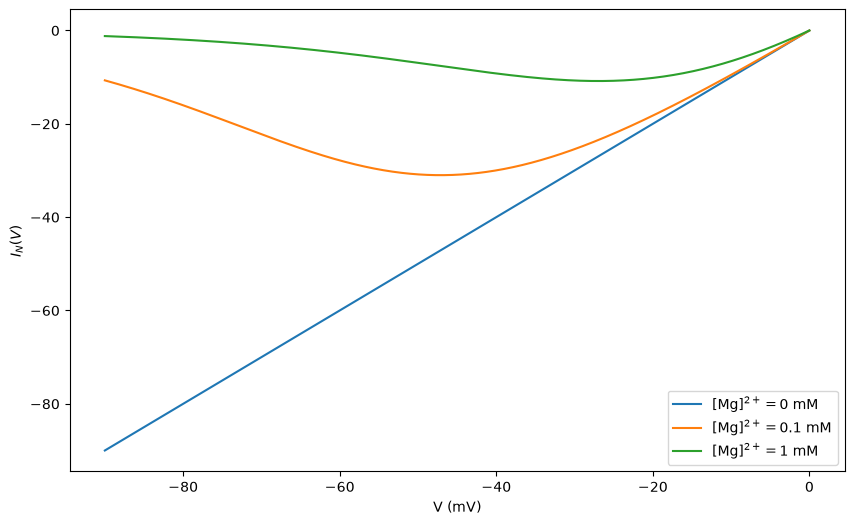

In [19]:
Vs = np.linspace(-90, 0, 1000)
I_N_0 = calculate_I_N(Vs, Mg2 = 0)
I_N_01 = calculate_I_N(Vs, Mg2 = 0.1)
I_N_1 = calculate_I_N(Vs, Mg2 = 1)

plt.figure(figsize = (10, 6))
plt.plot(Vs, I_N_0, label = "$\\text{[Mg]}^{2+} = 0$ mM")
plt.plot(Vs, I_N_01, label = "$\\text{[Mg]}^{2+} = 0.1$ mM")
plt.plot(Vs, I_N_1, label = "$\\text{[Mg]}^{2+} = 1$ mM")

plt.xlabel("V (mV)")
plt.ylabel("$I_N(V)$")

plt.legend()
plt.show()